# 02_osteo_eda

Objetivo:
- cargar el subset activo de Osteoarthritis,
- revisar distribución de clases y splits,
- inspeccionar tamaños, modos y calidad básica de las imágenes,
- detectar posibles archivos corruptos o duplicados,
- visualizar ejemplos por clase,
- dejar conclusiones útiles para el notebook de entrenamiento.

## Imports y rutas

In [1]:
from pathlib import Path
import json
import random
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ========= RUTAS FIJAS DEL PROYECTO =========
PROJECT_ROOT = Path("/mnt/d/Universidad/analitica/proyecto_analitica2")
DATA_DIR = PROJECT_ROOT / "data"
WORKING_DIR = DATA_DIR / "working"
MANIFESTS_DIR = DATA_DIR / "manifests"

DATASET_NAME = "osteo"

META_DIR = WORKING_DIR / DATASET_NAME / "meta"
SUBSETS_DIR = WORKING_DIR / DATASET_NAME / "subsets"

ACTIVE_SUBSET_PATH = META_DIR / f"{DATASET_NAME}_active_subset.csv"
MASTER_MANIFEST_PATH = MANIFESTS_DIR / f"{DATASET_NAME}_master_manifest.csv"
LABEL_MAP_PATH = META_DIR / f"{DATASET_NAME}_label_map.json"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("WORKING_DIR:", WORKING_DIR)
print("MANIFESTS_DIR:", MANIFESTS_DIR)
print("META_DIR:", META_DIR)
print("SUBSETS_DIR:", SUBSETS_DIR)
print("ACTIVE_SUBSET_PATH:", ACTIVE_SUBSET_PATH)
print("MASTER_MANIFEST_PATH:", MASTER_MANIFEST_PATH)
print("LABEL_MAP_PATH:", LABEL_MAP_PATH)

PROJECT_ROOT: /mnt/d/Universidad/analitica/proyecto_analitica2
DATA_DIR: /mnt/d/Universidad/analitica/proyecto_analitica2/data
WORKING_DIR: /mnt/d/Universidad/analitica/proyecto_analitica2/data/working
MANIFESTS_DIR: /mnt/d/Universidad/analitica/proyecto_analitica2/data/manifests
META_DIR: /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/osteo/meta
SUBSETS_DIR: /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/osteo/subsets
ACTIVE_SUBSET_PATH: /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/osteo/meta/osteo_active_subset.csv
MASTER_MANIFEST_PATH: /mnt/d/Universidad/analitica/proyecto_analitica2/data/manifests/osteo_master_manifest.csv
LABEL_MAP_PATH: /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/osteo/meta/osteo_label_map.json


## Cargar subset activo y label map

In [2]:
df = pd.read_csv(ACTIVE_SUBSET_PATH)
master_df = pd.read_csv(MASTER_MANIFEST_PATH)

with open(LABEL_MAP_PATH, "r", encoding="utf-8") as f:
    label_map = json.load(f)

label_to_idx = label_map["label_to_idx"]
idx_to_label = {int(k): v for k, v in label_map["idx_to_label"].items()}

print("Shape active subset:", df.shape)
print("Shape master manifest:", master_df.shape)
print("label_to_idx:", label_to_idx)
print("idx_to_label:", idx_to_label)

display(df.head())

Shape active subset: (4766, 8)
Shape master manifest: (4766, 7)
label_to_idx: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}
idx_to_label: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4'}


,image_id,filename,file_path,label_text,target_label,split,source_dataset,subset_name
0,SevereG4 (233),SevereG4 (233).png,/mnt/d/Universidad/analitica/proyecto_analitic...,4,4,train,osteo,large
1,grade_2_164_png.rf.cf42a3f0b781d99bc4c5c408c8c...,grade_2_164_png.rf.cf42a3f0b781d99bc4c5c408c8c...,/mnt/d/Universidad/analitica/proyecto_analitic...,2,2,train,osteo,large
2,MildG2 (232),MildG2 (232).png,/mnt/d/Universidad/analitica/proyecto_analitic...,2,2,train,osteo,large
3,NormalG0 (64),NormalG0 (64).png,/mnt/d/Universidad/analitica/proyecto_analitic...,0,0,val,osteo,large
4,MildG2 (144),MildG2 (144).png,/mnt/d/Universidad/analitica/proyecto_analitic...,2,2,train,osteo,large


## Confirmar que el subset activo es large

In [3]:
if "subset_name" in df.columns:
    print("Subset activo detectado:", df["subset_name"].value_counts(dropna=False).to_dict())
else:
    print("⚠️ No existe la columna subset_name en el active subset.")
    print("Se asumirá que el archivo activo ya corresponde al subset correcto.")

print("\nConteo por split:")
display(df["split"].value_counts().rename_axis("split").reset_index(name="count"))

Subset activo detectado: {'large': 4766}

Conteo por split:


,split,count
0,train,3336
1,val,715
2,test,715


## Información general del dataset activo

In [4]:
print("Número total de filas:", len(df))
print("Número de clases:", df["label_text"].nunique())
print("Clases detectadas:", sorted(df["label_text"].astype(str).unique().tolist()))
print("Splits detectados:", df["split"].unique().tolist())

print("\nTipos de datos:")
display(df.dtypes)

print("\nValores nulos por columna:")
display(df.isnull().sum().rename_axis("column").reset_index(name="null_count"))

Número total de filas: 4766
Número de clases: 5
Clases detectadas: ['0', '1', '2', '3', '4']
Splits detectados: ['train', 'val', 'test']

Tipos de datos:


image_id          object
filename          object
file_path         object
label_text         int64
target_label       int64
split             object
source_dataset    object
subset_name       object
dtype: object


Valores nulos por columna:


,column,null_count
0,image_id,0
1,filename,0
2,file_path,0
3,label_text,0
4,target_label,0
5,split,0
6,source_dataset,0
7,subset_name,0


## Distribución global de clases

,label_text,count,ratio
0,0,1315,0.275913
1,1,1266,0.265632
2,2,765,0.160512
3,3,742,0.155686
4,4,678,0.142258


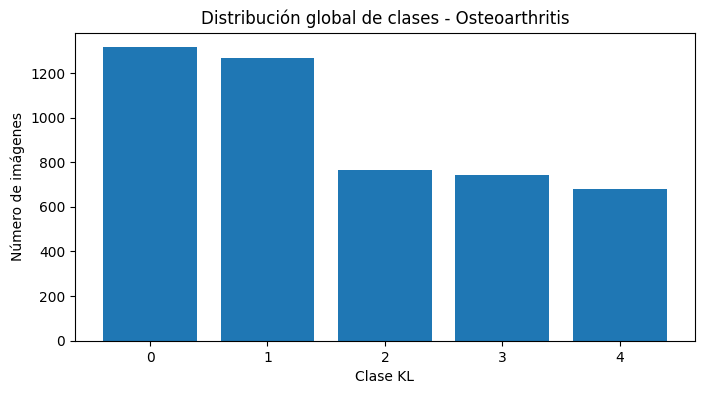

In [5]:
class_counts = (
    df["label_text"]
    .astype(str)
    .value_counts()
    .sort_index()
    .rename_axis("label_text")
    .reset_index(name="count")
)

class_counts["ratio"] = class_counts["count"] / class_counts["count"].sum()

display(class_counts)

plt.figure(figsize=(8, 4))
plt.bar(class_counts["label_text"], class_counts["count"])
plt.title("Distribución global de clases - Osteoarthritis")
plt.xlabel("Clase KL")
plt.ylabel("Número de imágenes")
plt.show()

## Distribución de clases por split

In [6]:
split_class_counts = (
    df.groupby(["split", "label_text"])
    .size()
    .reset_index(name="count")
    .sort_values(["split", "label_text"])
)

display(split_class_counts)

pivot_split_class = split_class_counts.pivot(index="label_text", columns="split", values="count").fillna(0).astype(int)
display(pivot_split_class)

,split,label_text,count
0,test,0,197
1,test,1,190
2,test,2,115
3,test,3,111
4,test,4,102
5,train,0,921
6,train,1,886
7,train,2,535
8,train,3,520
9,train,4,474


split,test,train,val
label_text,,,
0,197,921,197
1,190,886,190
2,115,535,115
3,111,520,111
4,102,474,102


## Proporciones por split

,split,label_text,count,split_total,ratio_within_split
0,test,0,197,715,0.275524
1,test,1,190,715,0.265734
2,test,2,115,715,0.160839
3,test,3,111,715,0.155245
4,test,4,102,715,0.142657
5,train,0,921,3336,0.276079
6,train,1,886,3336,0.265588
7,train,2,535,3336,0.160372
8,train,3,520,3336,0.155875
9,train,4,474,3336,0.142086


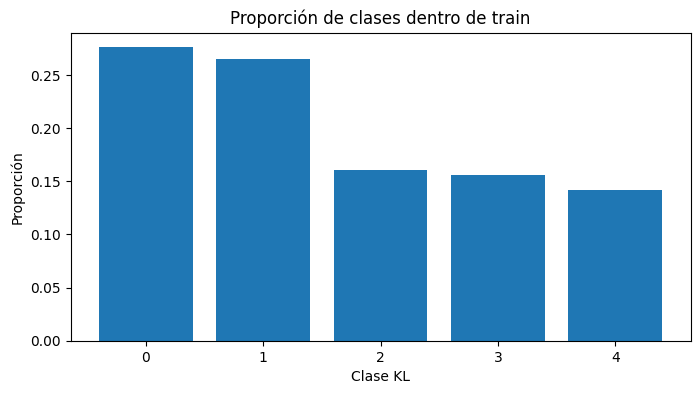

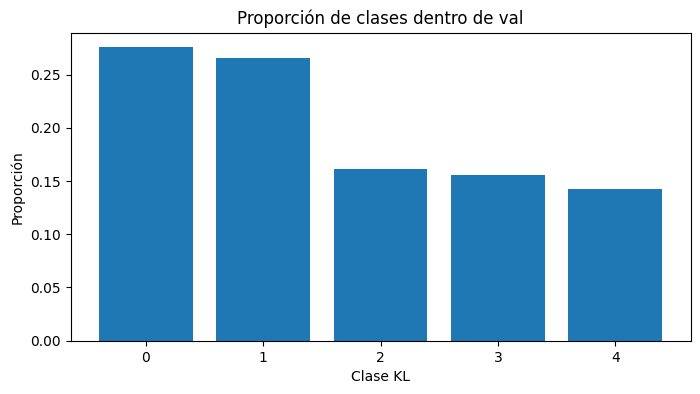

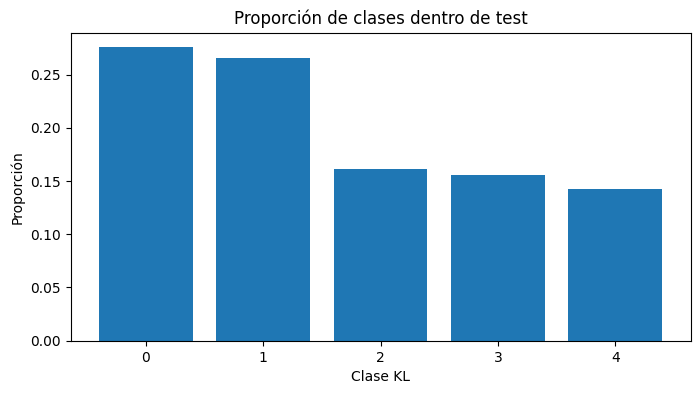

In [7]:
split_sizes = df["split"].value_counts().to_dict()

split_class_props = split_class_counts.copy()
split_class_props["split_total"] = split_class_props["split"].map(split_sizes)
split_class_props["ratio_within_split"] = split_class_props["count"] / split_class_props["split_total"]

display(split_class_props)

for split_name in ["train", "val", "test"]:
    tmp = split_class_props[split_class_props["split"] == split_name].copy()
    plt.figure(figsize=(8, 4))
    plt.bar(tmp["label_text"].astype(str), tmp["ratio_within_split"])
    plt.title(f"Proporción de clases dentro de {split_name}")
    plt.xlabel("Clase KL")
    plt.ylabel("Proporción")
    plt.show()

## Verificar existencia real de archivos

In [8]:
df["file_exists"] = df["file_path"].apply(lambda x: Path(x).exists())

exists_summary = (
    df["file_exists"]
    .value_counts(dropna=False)
    .rename_axis("file_exists")
    .reset_index(name="count")
)

display(exists_summary)

missing_files = df[~df["file_exists"]].copy()
print("Archivos faltantes:", len(missing_files))

if len(missing_files) > 0:
    display(missing_files.head(20))

,file_exists,count
0,True,4766


Archivos faltantes: 0


## Duplicados básicos

In [9]:
dup_image_id = df["image_id"].duplicated().sum() if "image_id" in df.columns else None
dup_filename = df["filename"].duplicated().sum() if "filename" in df.columns else None
dup_file_path = df["file_path"].duplicated().sum()

print("Duplicados por image_id:", dup_image_id)
print("Duplicados por filename:", dup_filename)
print("Duplicados por file_path:", dup_file_path)

if dup_file_path > 0:
    display(df[df["file_path"].duplicated(keep=False)].sort_values("file_path").head(20))

Duplicados por image_id: 0
Duplicados por filename: 0
Duplicados por file_path: 0


## Leer metadata básica de imágenes

In [13]:
def get_image_info(path_str):
    path = Path(path_str)
    try:
        with Image.open(path) as img:
            width, height = img.size
            mode = img.mode
            return {
                "width": width,
                "height": height,
                "mode": mode,
                "ok": True,
                "error": None
            }
    except Exception as e:
        return {
            "width": None,
            "height": None,
            "mode": None,
            "ok": False,
            "error": str(e)
        }

image_info_rows = []
for fp in df["file_path"]:
    info = get_image_info(fp)
    image_info_rows.append(info)

image_info_df = pd.DataFrame(image_info_rows)
eda_df = pd.concat([df.reset_index(drop=True), image_info_df.reset_index(drop=True)], axis=1)

print("Shape eda_df:", eda_df.shape)
display(eda_df.head())

Shape eda_df: (4766, 14)


,image_id,filename,file_path,label_text,target_label,split,source_dataset,subset_name,file_exists,width,height,mode,ok,error
0,SevereG4 (233),SevereG4 (233).png,/mnt/d/Universidad/analitica/proyecto_analitic...,4,4,train,osteo,large,True,300,162,RGB,True,None
1,grade_2_164_png.rf.cf42a3f0b781d99bc4c5c408c8c...,grade_2_164_png.rf.cf42a3f0b781d99bc4c5c408c8c...,/mnt/d/Universidad/analitica/proyecto_analitic...,2,2,train,osteo,large,True,640,640,RGB,True,None
2,MildG2 (232),MildG2 (232).png,/mnt/d/Universidad/analitica/proyecto_analitic...,2,2,train,osteo,large,True,640,161,RGB,True,None
3,NormalG0 (64),NormalG0 (64).png,/mnt/d/Universidad/analitica/proyecto_analitic...,0,0,val,osteo,large,True,300,162,RGB,True,None
4,MildG2 (144),MildG2 (144).png,/mnt/d/Universidad/analitica/proyecto_analitic...,2,2,train,osteo,large,True,300,162,RGB,True,None


## Imágenes corruptas o con error de lectura

In [14]:
read_ok_counts = (
    eda_df["ok"]
    .value_counts(dropna=False)
    .rename_axis("ok")
    .reset_index(name="count")
)

display(read_ok_counts)

bad_images = eda_df[~eda_df["ok"]].copy()
print("Cantidad de imágenes con error:", len(bad_images))

if len(bad_images) > 0:
    display(bad_images[["file_path", "error", "label_text", "split"]].head(20))

,ok,count
0,True,4766


Cantidad de imágenes con error: 0


## Tamaños de imagen

In [15]:
valid_img_df = eda_df[eda_df["ok"]].copy()

size_summary = valid_img_df[["width", "height"]].describe()
display(size_summary)

print("Top tamaños más frecuentes:")
display(
    valid_img_df.groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(20)
)

,width,height
count,4766.000000,4766.000000
mean,431.120436,308.952581
std,165.511714,220.671424
min,300.000000,161.000000
25%,300.000000,162.000000
50%,300.000000,162.000000
75%,640.000000,640.000000
max,640.000000,640.000000


Top tamaños más frecuentes:


,width,height,count
0,300,162,2928
2,640,640,1466
1,640,161,372


## Modos de imagen

In [16]:
mode_counts = (
    valid_img_df["mode"]
    .value_counts(dropna=False)
    .rename_axis("mode")
    .reset_index(name="count")
)

display(mode_counts)

,mode,count
0,RGB,4606
1,I;16,160


## Estadísticas simples de aspecto

count    4766.000000
mean        1.755556
std         0.752295
min         1.000000
25%         1.000000
50%         1.851852
75%         1.851852
max         3.975155
Name: aspect_ratio, dtype: float64

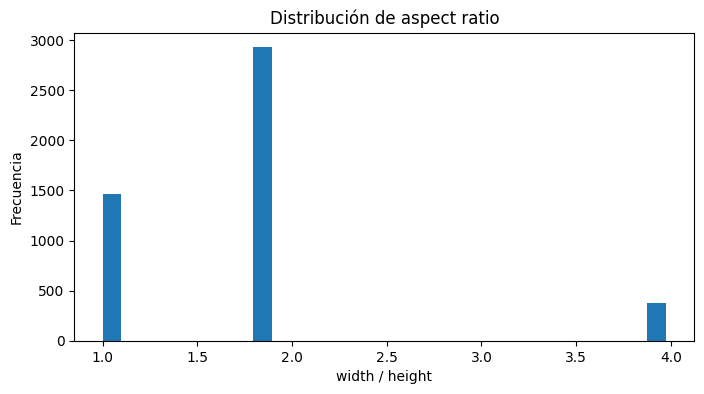

In [17]:
valid_img_df["aspect_ratio"] = valid_img_df["width"] / valid_img_df["height"]

display(valid_img_df["aspect_ratio"].describe())

plt.figure(figsize=(8, 4))
plt.hist(valid_img_df["aspect_ratio"], bins=30)
plt.title("Distribución de aspect ratio")
plt.xlabel("width / height")
plt.ylabel("Frecuencia")
plt.show()

## Muestra aleatoria por clase

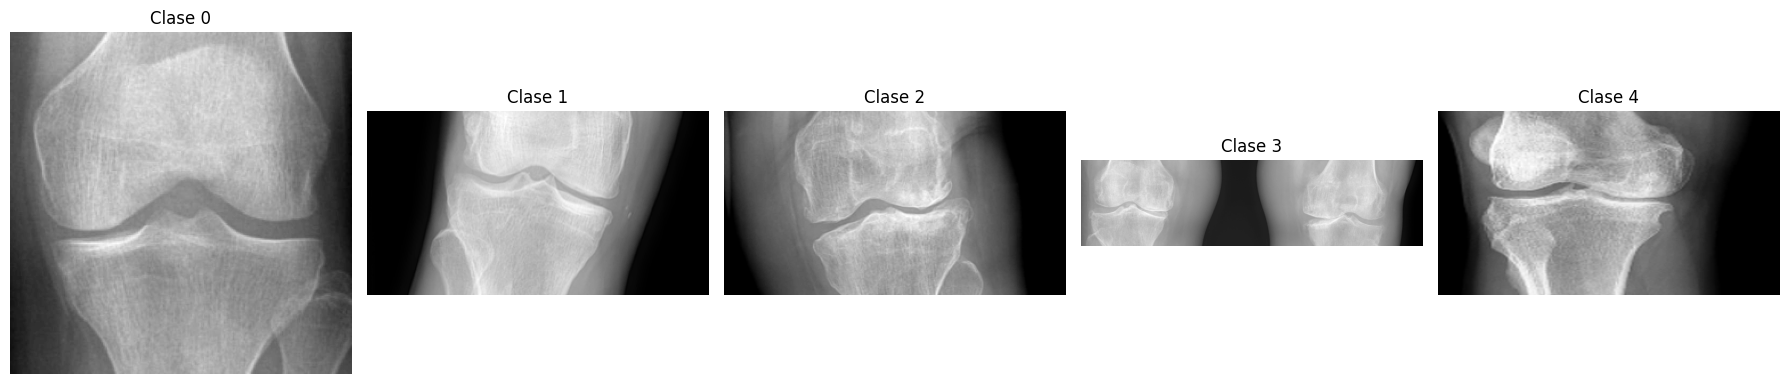

In [18]:
def load_image_for_plot(path_str):
    path = Path(path_str)
    with Image.open(path) as img:
        return img.convert("L")

classes_sorted = sorted(valid_img_df["label_text"].astype(str).unique().tolist(), key=lambda x: int(x))

rows = []
for cls in classes_sorted:
    sample_row = valid_img_df[valid_img_df["label_text"].astype(str) == cls].sample(1, random_state=SEED)
    rows.append(sample_row.iloc[0])

sample_per_class_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, len(sample_per_class_df), figsize=(18, 4))
if len(sample_per_class_df) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, sample_per_class_df.iterrows()):
    img = load_image_for_plot(row["file_path"])
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Clase {row['label_text']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Más ejemplos por clase

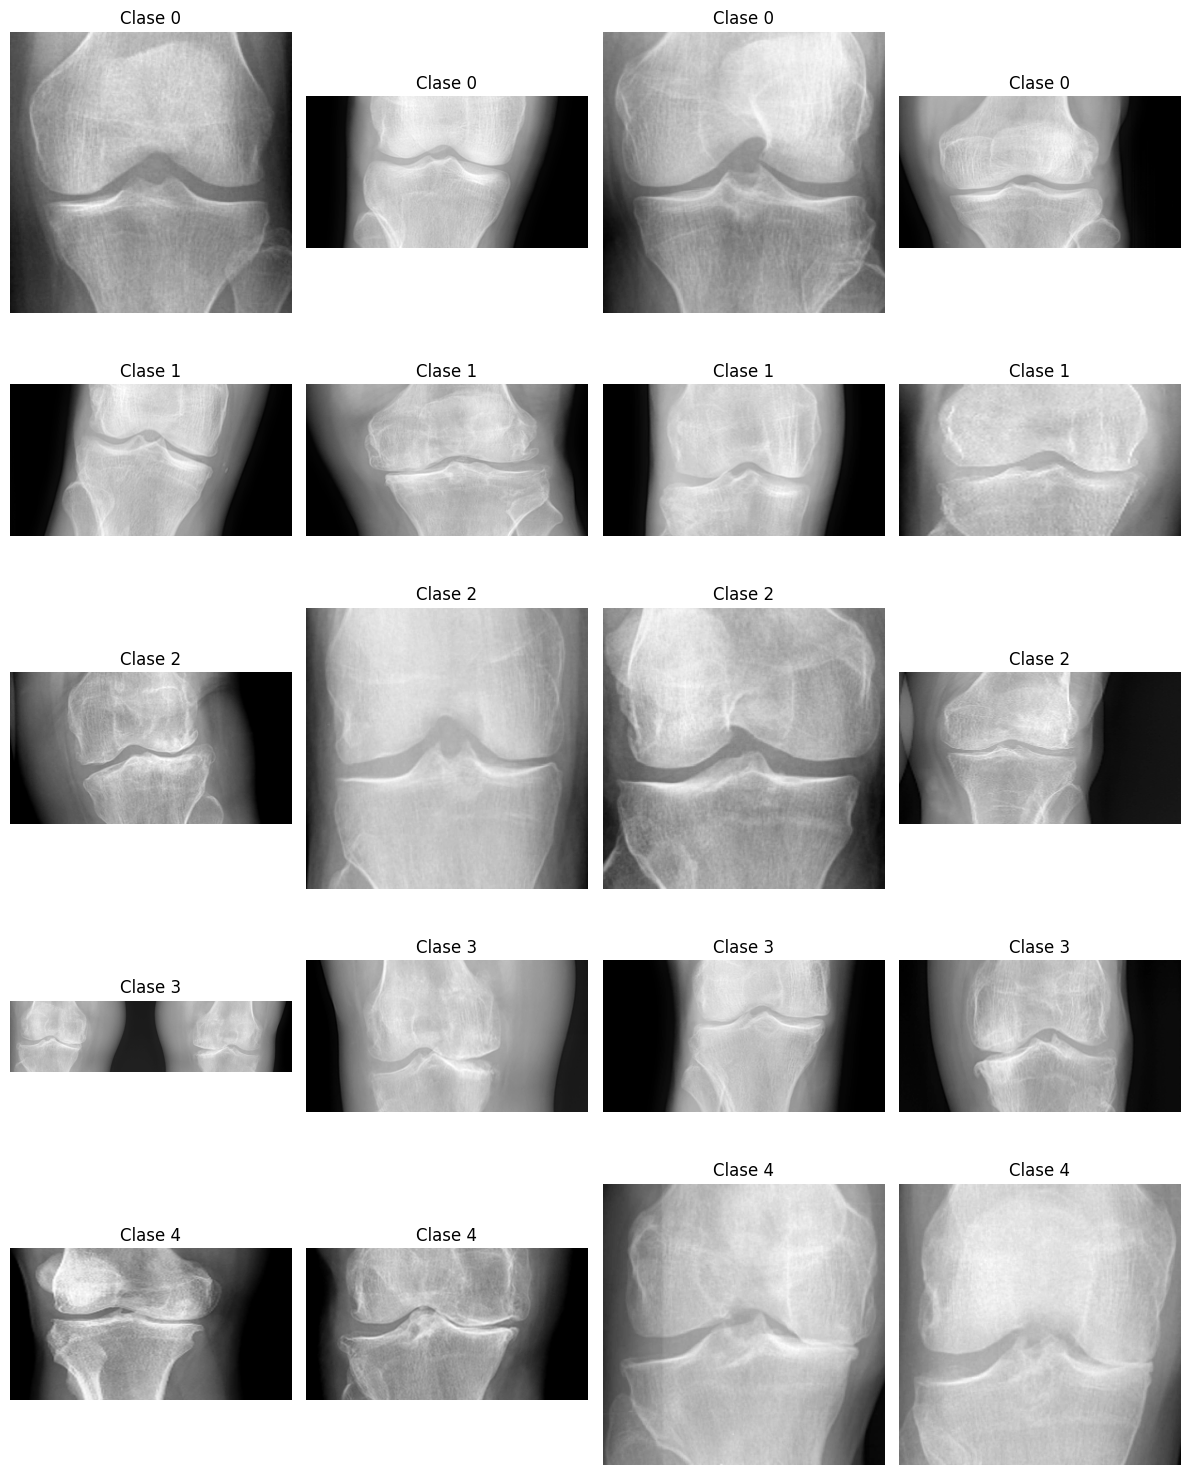

In [19]:
N_PER_CLASS = 4
classes_sorted = sorted(valid_img_df["label_text"].astype(str).unique().tolist(), key=lambda x: int(x))

fig, axes = plt.subplots(len(classes_sorted), N_PER_CLASS, figsize=(12, 3 * len(classes_sorted)))

if len(classes_sorted) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, cls in enumerate(classes_sorted):
    cls_df = valid_img_df[valid_img_df["label_text"].astype(str) == cls].sample(
        n=min(N_PER_CLASS, len(valid_img_df[valid_img_df["label_text"].astype(str) == cls])),
        random_state=SEED
    ).reset_index(drop=True)

    for j in range(N_PER_CLASS):
        ax = axes[i, j]
        if j < len(cls_df):
            img = load_image_for_plot(cls_df.loc[j, "file_path"])
            ax.imshow(img, cmap="gray")
            ax.set_title(f"Clase {cls}")
        ax.axis("off")

plt.tight_layout()
plt.show()

## Intensidad promedio simple por imagen

In [20]:
def compute_gray_stats(path_str):
    path = Path(path_str)
    try:
        with Image.open(path) as img:
            gray = np.array(img.convert("L"), dtype=np.float32)
            return gray.mean(), gray.std(), gray.min(), gray.max()
    except Exception:
        return np.nan, np.nan, np.nan, np.nan

gray_stats = [compute_gray_stats(fp) for fp in valid_img_df["file_path"]]
gray_stats_df = pd.DataFrame(gray_stats, columns=["gray_mean", "gray_std", "gray_min", "gray_max"])

valid_img_df = pd.concat([valid_img_df.reset_index(drop=True), gray_stats_df.reset_index(drop=True)], axis=1)

display(valid_img_df[["gray_mean", "gray_std", "gray_min", "gray_max"]].describe())

,gray_mean,gray_std,gray_min,gray_max
count,4766.000000,4766.000000,4766.000000,4766.000000
mean,133.233185,52.247120,19.724926,220.940826
std,31.371494,17.454573,30.407820,21.274448
min,40.448643,0.000000,0.000000,117.000000
25%,111.911644,38.497190,0.000000,205.000000
50%,131.602547,53.662514,0.000000,222.000000
75%,152.414318,64.862122,34.000000,237.000000
max,255.000000,114.165665,255.000000,255.000000


## Intensidad por clase

In [21]:
gray_by_class = (
    valid_img_df.groupby("label_text")[["gray_mean", "gray_std"]]
    .agg(["mean", "std"])
)

display(gray_by_class)

gray_mean              gray_std           
                  mean        std       mean        std
label_text                                             
0           133.652618  30.902296  57.214474  17.856947
1           129.912094  25.789251  52.399406  15.554873
2           133.908768  35.784683  51.022282  19.351305
3           134.112610  36.891357  49.950371  17.196089
4           136.896317  29.330332  46.224018  15.339464

## Resumen EDA para entrenamiento

In [22]:
summary = {
    "n_rows_active_subset": int(len(df)),
    "n_rows_valid_images": int(len(valid_img_df)),
    "n_classes": int(df["label_text"].nunique()),
    "classes": sorted(df["label_text"].astype(str).unique().tolist(), key=lambda x: int(x)),
    "split_counts": df["split"].value_counts().to_dict(),
    "class_counts": df["label_text"].astype(str).value_counts().sort_index().to_dict(),
    "mode_counts": valid_img_df["mode"].value_counts(dropna=False).to_dict(),
    "n_missing_files": int((~df["file_exists"]).sum()),
    "n_bad_images": int((~eda_df["ok"]).sum()),
}

summary

{'n_rows_active_subset': 4766,
 'n_rows_valid_images': 4766,
 'n_classes': 5,
 'classes': ['0', '1', '2', '3', '4'],
 'split_counts': {'train': 3336, 'val': 715, 'test': 715},
 'class_counts': {'0': 1315, '1': 1266, '2': 765, '3': 742, '4': 678},
 'mode_counts': {'RGB': 4606, 'I;16': 160},
 'n_missing_files': 0,
 'n_bad_images': 0}

## Guardar reporte EDA básico

In [23]:
EDA_OUTPUT_DIR = WORKING_DIR / DATASET_NAME / "eda"
EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

summary_path = EDA_OUTPUT_DIR / f"{DATASET_NAME}_eda_summary.json"
class_counts_path = EDA_OUTPUT_DIR / f"{DATASET_NAME}_class_counts.csv"
split_class_counts_path = EDA_OUTPUT_DIR / f"{DATASET_NAME}_split_class_counts.csv"
image_info_path = EDA_OUTPUT_DIR / f"{DATASET_NAME}_image_info.csv"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

class_counts.to_csv(class_counts_path, index=False)
split_class_counts.to_csv(split_class_counts_path, index=False)
eda_df.to_csv(image_info_path, index=False)

print("Guardado en:")
print("-", summary_path)
print("-", class_counts_path)
print("-", split_class_counts_path)
print("-", image_info_path)

Guardado en:
- /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/osteo/eda/osteo_eda_summary.json
- /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/osteo/eda/osteo_class_counts.csv
- /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/osteo/eda/osteo_split_class_counts.csv
- /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/osteo/eda/osteo_image_info.csv
